# 03 — Exploratory Data Analysis

## Purpose
This notebook explores the cleaned staging datasets to understand business patterns before:
- PostgreSQL validation
- SQL view creation
- Tableau dashboard design
- customer segmentation
- anomaly detection
- forecasting

## Stage 1
In this stage, we will:
- load the staging sales dataset
- load the non-merchandise reference list
- confirm dataset structure
- prepare the notebook for merchandise-aware analysis

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
staging_path = project_root / "data" / "staging"

sales_main_path = staging_path / "sales_main.csv"
non_merch_path = staging_path / "non_merchandise_codes.csv"

print("Sales main exists:", sales_main_path.exists())
print("Non-merchandise file exists:", non_merch_path.exists())
print("Staging path:", staging_path)

Sales main exists: True
Non-merchandise file exists: True
Staging path: /Users/pratikchetry/Desktop/retail-revenue-intelligence/data/staging


In [4]:
sales_main = pd.read_csv(sales_main_path, parse_dates=["invoicedate"], low_memory=False)
non_merchandise_codes = pd.read_csv(non_merch_path)

print("sales_main shape:", sales_main.shape)
print("non_merchandise_codes shape:", non_merchandise_codes.shape)

sales_main.head()

sales_main shape: (1007914, 9)
non_merchandise_codes shape: (3, 7)


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
sales_main.info()
non_merchandise_codes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007914 entries, 0 to 1007913
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   invoice      1007914 non-null  object        
 1   stockcode    1007914 non-null  object        
 2   description  1007914 non-null  object        
 3   quantity     1007914 non-null  int64         
 4   invoicedate  1007914 non-null  datetime64[ns]
 5   price        1007914 non-null  float64       
 6   customer_id  779425 non-null   float64       
 7   country      1007914 non-null  object        
 8   revenue      1007914 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 69.2+ MB


,stockcode,description,total_revenue,total_quantity,total_orders,product_type,is_merchandise
0,M,Manual,339599.81,9630,785,service/manual,False
1,DOT,DOTCOM POSTAGE,309854.11,1415,1415,postage/service,False
2,POST,POSTAGE,125682.42,5363,1851,postage/service,False


## Stage 1 result — EDA inputs confirmed

The EDA notebook is now correctly connected to the permanent staging layer.

### Confirmed active inputs
- `sales_main.csv` with **1,007,914 rows** and **9 columns**
- `non_merchandise_codes.csv` with **3 confirmed non-merchandise stock codes**

### Confirmed non-merchandise codes
- `M` → Manual
- `DOT` → DOTCOM POSTAGE
- `POST` → POSTAGE

### Business implication
This means product analysis can no longer treat all stock codes as equal merchandise items. Some high-revenue entries are operational or service-like and must be separated in later product reporting.

### Design implication
From this point onward:
- revenue analysis can use the full sales staging table
- product analysis must support merchandise vs non-merchandise logic
- Tableau and SQL views must later make this distinction explicit

## Stage 2 — Basic revenue and volume profile

In this stage, we establish the core business scale of the cleaned sales staging dataset.

We will check:
- total revenue
- total quantity
- total invoices
- total products
- total countries
- line-level revenue distribution

In [6]:
total_revenue = round(sales_main["revenue"].sum(), 2)
total_quantity = int(sales_main["quantity"].sum())
total_invoices = int(sales_main["invoice"].nunique())
total_products = int(sales_main["stockcode"].nunique())
total_countries = int(sales_main["country"].nunique())

print("Total revenue:", total_revenue)
print("Total quantity:", total_quantity)
print("Total invoices:", total_invoices)
print("Total products:", total_products)
print("Total countries:", total_countries)

Total revenue: 20476634.02
Total quantity: 11205149
Total invoices: 40078
Total products: 4917
Total countries: 43


In [7]:
revenue_summary = sales_main["revenue"].describe()
display(revenue_summary)

count    1.007914e+06
mean     2.031585e+01
std      2.057160e+02
min      1.000000e-03
25%      4.130000e+00
50%      1.008000e+01
75%      1.770000e+01
max      1.684696e+05
Name: revenue, dtype: float64

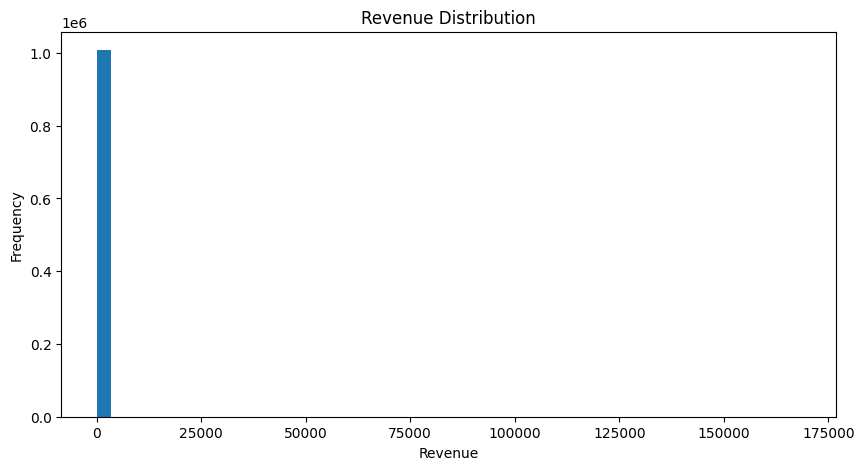

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(sales_main["revenue"], bins=50)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

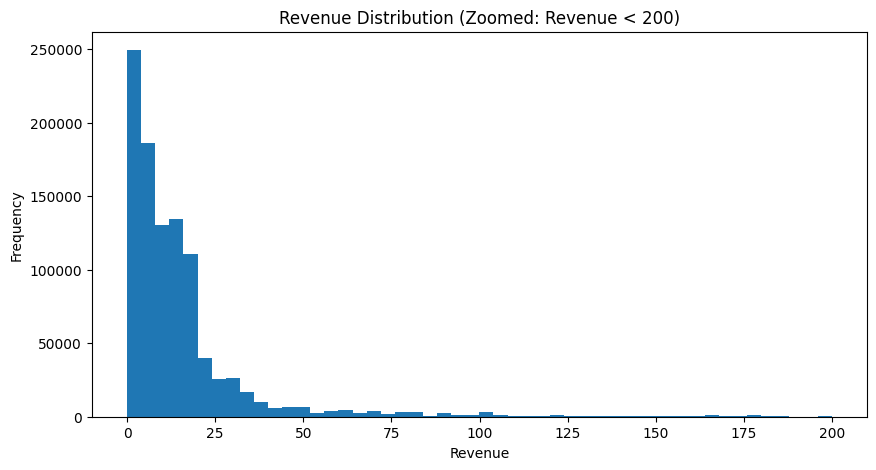

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(sales_main[sales_main["revenue"] < 200]["revenue"], bins=50)
plt.title("Revenue Distribution (Zoomed: Revenue < 200)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

## Stage 2 result — revenue and volume profile

The cleaned staging sales dataset represents a large retail sales base with:

- **20,476,634.02** total revenue
- **11,205,149** total quantity sold
- **40,078** unique invoices
- **4,917** unique stock codes
- **43** countries

### Revenue distribution
Line-level revenue is highly right-skewed:

- mean revenue per row: **20.32**
- median revenue per row: **10.08**
- 75th percentile: **17.70**
- maximum row revenue: **168,469.60**

### Business implication
This means the dataset is driven by many relatively small transaction lines and a much smaller number of very large lines. Average values alone would be misleading without distribution-aware analysis.

### Design implication
Later stages must account for this skew:
- anomaly detection should not assume a normal distribution
- dashboard summaries should use both totals and distributions
- validation benchmarks should use the confirmed totals from this stage

## Stage 3 — Geographic concentration

In this stage, we examine country-level revenue concentration.

The goal is to understand:
- which countries drive most of the business
- whether global metrics are dominated by one geography
- what this means for dashboard design

In [10]:
country_summary = (
    sales_main.groupby("country", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("invoice", "nunique"),
        total_quantity=("quantity", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

display(country_summary.head(10))

,country,total_revenue,total_orders,total_quantity
40,United Kingdom,1.741057e+07,36536,9187754
11,EIRE,6.587673e+05,626,336329
26,Netherlands,5.540381e+05,228,383879
15,Germany,4.250197e+05,789,225154
14,France,3.504561e+05,622,271901
0,Australia,1.692835e+05,95,103759
34,Spain,1.083325e+05,154,50307
36,Switzerland,1.006856e+05,93,52762
35,Sweden,9.186982e+04,105,88633
10,Denmark,6.858069e+04,43,237471


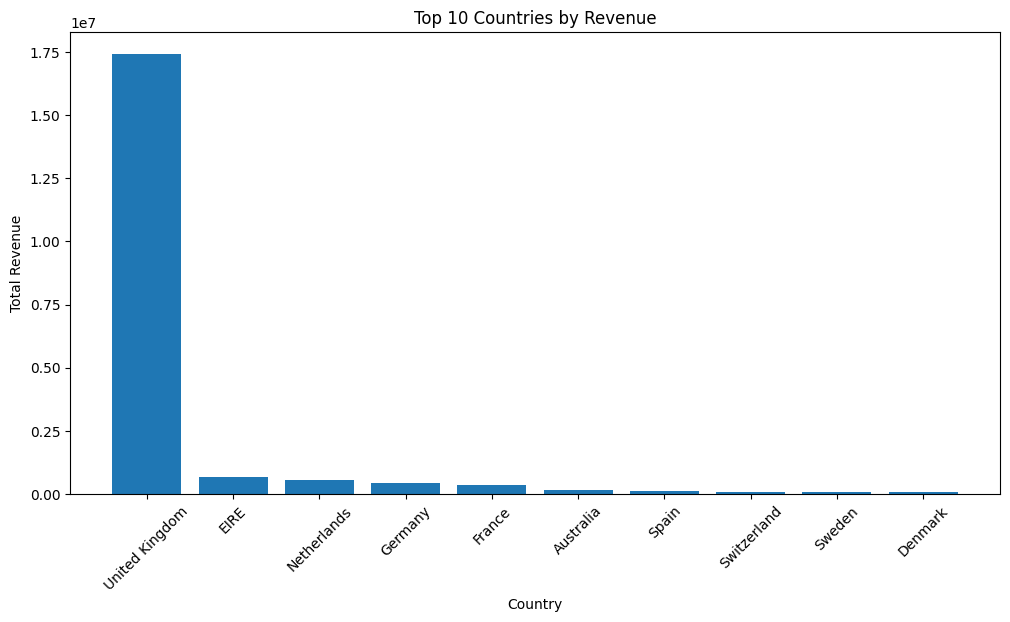

In [11]:
top_10_countries = country_summary.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_countries["country"], top_10_countries["total_revenue"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [12]:
uk_revenue = country_summary.loc[country_summary["country"] == "United Kingdom", "total_revenue"].iloc[0]
uk_share_pct = (uk_revenue / total_revenue) * 100

print("United Kingdom revenue:", round(uk_revenue, 2))
print("United Kingdom share of total revenue (%):", round(uk_share_pct, 2))

United Kingdom revenue: 17410569.69
United Kingdom share of total revenue (%): 85.03


## Stage 3 result — geographic concentration

Country-level revenue is highly concentrated.

### Confirmed result
The **United Kingdom** contributes **17,410,569.69** of total revenue, which is **85.03%** of the full cleaned sales revenue base.

The next strongest countries are much smaller:
- **EIRE** → **658,767.33**
- **Netherlands** → **554,038.10**
- **Germany** → **425,019.67**
- **France** → **350,456.06**

### Business implication
This means any “global” revenue metric is effectively a **UK-driven metric with smaller markets hidden inside it**. Without segmentation, country comparisons will be visually dominated by the United Kingdom.

### Design implication
All dashboards must support **UK vs Non-UK segmentation as a primary filter**, not as an optional afterthought. Country analysis should also include:
- a full global view
- a Non-UK comparison view
so that smaller markets are not visually flattened.

## Stage 4 — Time-series behavior and seasonality

In this stage, we examine:
- daily revenue movement
- monthly revenue trend
- month-level seasonality

The goal is to understand:
- whether revenue is stable or volatile
- whether clear seasonal peaks exist
- what this implies for anomaly detection and forecasting

In [13]:
sales_main["order_date"] = sales_main["invoicedate"].dt.date

daily_sales = (
    sales_main.groupby("order_date", as_index=False)
    .agg(
        daily_revenue=("revenue", "sum"),
        daily_quantity=("quantity", "sum"),
        daily_orders=("invoice", "nunique")
    )
)

display(daily_sales.head())
print("Daily sales rows:", len(daily_sales))

,order_date,daily_revenue,daily_quantity,daily_orders
0,2009-12-01,54351.23,26098,119
1,2009-12-02,63172.58,31804,115
2,2009-12-03,73972.45,49221,124
3,2009-12-04,40582.32,21210,89
4,2009-12-05,9803.05,5119,30


Daily sales rows: 604


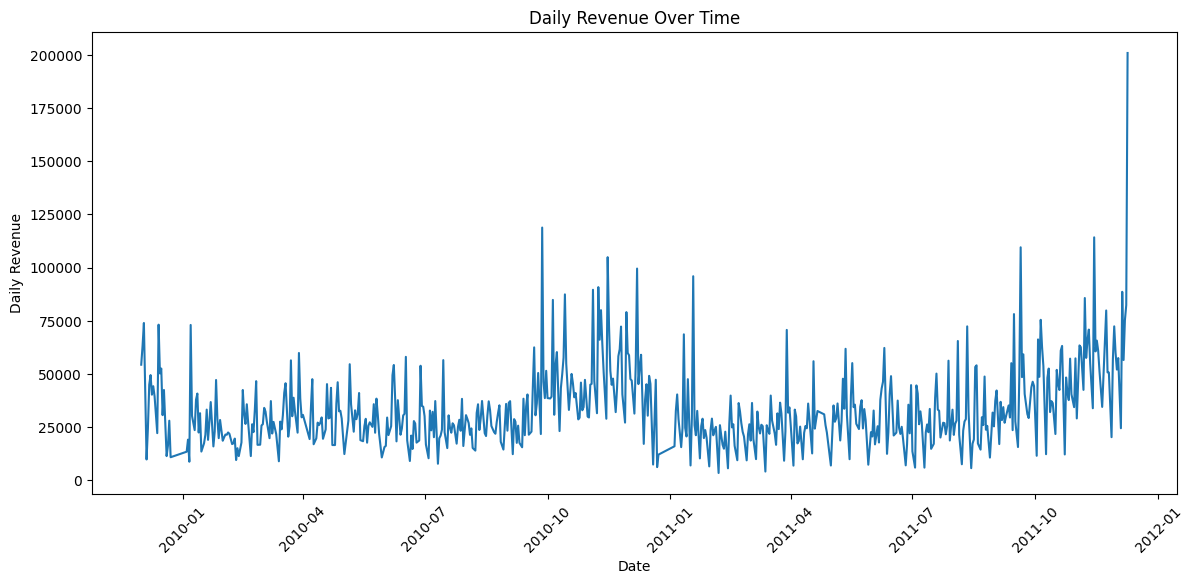

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(daily_sales["order_date"], daily_sales["daily_revenue"])
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.xticks(rotation=45)
plt.show()

In [15]:
sales_main["year_month"] = sales_main["invoicedate"].dt.to_period("M").astype(str)

monthly_sales = (
    sales_main.groupby("year_month", as_index=False)
    .agg(
        monthly_revenue=("revenue", "sum"),
        monthly_orders=("invoice", "nunique")
    )
)

display(monthly_sales.head())
print("Monthly sales rows:", len(monthly_sales))

,year_month,monthly_revenue,monthly_orders
0,2009-12,822483.950,1682
1,2010-01,651155.112,1105
2,2010-02,551878.296,1202
3,2010-03,830915.261,1681
4,2010-04,678875.252,1462


Monthly sales rows: 25


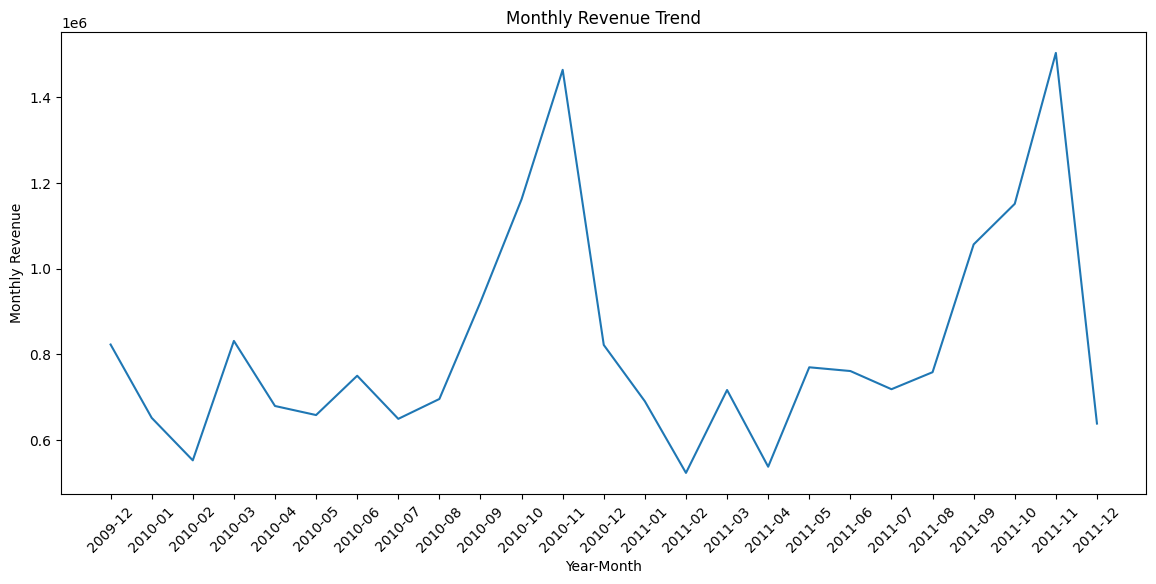

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales["year_month"], monthly_sales["monthly_revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.show()

In [17]:
sales_main["month"] = sales_main["invoicedate"].dt.month

monthly_revenue_summary = (
    sales_main.groupby("month", as_index=False)
    .agg(total_revenue=("revenue", "sum"))
    .sort_values("month")
)

display(monthly_revenue_summary)

,month,total_revenue
0,1,1340966.722
1,2,1074423.856
2,3,1547130.521
3,4,1215843.743
4,5,1427002.110
5,6,1510084.320
6,7,1366886.391
7,8,1453093.290
8,9,1978132.183
9,10,2313165.950


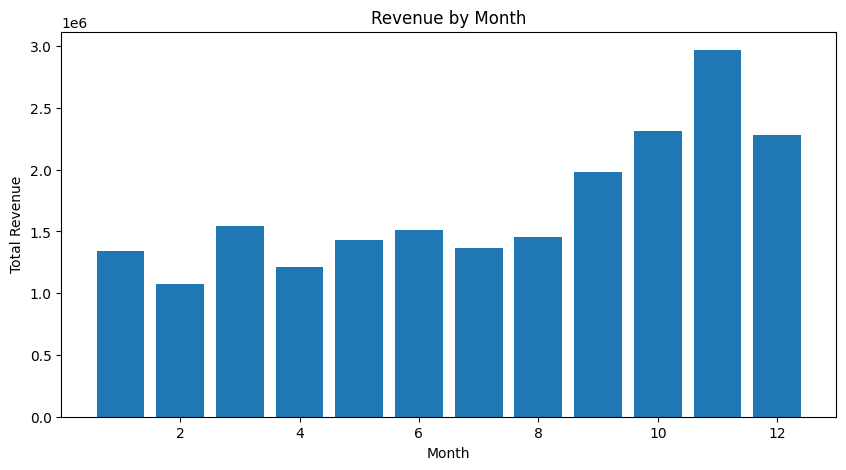

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_revenue_summary["month"], monthly_revenue_summary["total_revenue"])
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

## Stage 4 result — time-series behavior and seasonality

The cleaned sales staging dataset contains **604 daily observations** and **25 monthly periods**.

### Confirmed monthly seasonality
Revenue peaks strongly in late-year months:

- **November** → **2,968,159.92**
- **October** → **2,313,165.95**
- **December** → **2,281,745.01**

Lower months include:
- **February** → **1,074,423.86**
- **April** → **1,215,843.74**
- **July** → **1,366,886.39**

### Daily movement
Daily revenue fluctuates substantially, with visible spikes and dips across the full time series.

### Business implication
This is not a flat retail business. Revenue is seasonal and volatile. The strongest demand period is concentrated in the late-year window, especially October to November.

### Design implication
This has direct consequences for later modeling and reporting:

- anomaly detection must allow for naturally high seasonal peaks rather than treating all spikes as abnormal
- forecasting must preserve seasonality instead of assuming stable averages
- year-over-year comparisons must align equivalent seasonal periods
- partial-period comparisons will be misleading if they compare weak-season months to peak-season months

## Stage 5 — Product analysis with merchandise awareness

In this stage, we examine product-level revenue and quantity.

Because non-merchandise stock codes are present in the staging layer, product analysis must be read carefully.

We will look at:
- top stock codes by revenue
- top stock codes by quantity
- product rankings before merchandise filtering

In [19]:
product_summary = (
    sales_main.groupby(["stockcode", "description"], as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_quantity=("quantity", "sum"),
        total_orders=("invoice", "nunique")
    )
)

top_10_products_revenue = product_summary.sort_values("total_revenue", ascending=False).head(10)
display(top_10_products_revenue)

,stockcode,description,total_revenue,total_quantity,total_orders
5615,M,Manual,339599.81,9630,785
1891,22423,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918
5614,DOT,DOTCOM POSTAGE,309854.11,1415,1415
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3716,47566,PARTY BUNTING,148318.28,28200,2674
4967,85099B,JUMBO BAG RED RETROSPOT,145961.83,77280,3245
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807
5617,POST,POSTAGE,125682.42,5363,1851
1477,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018


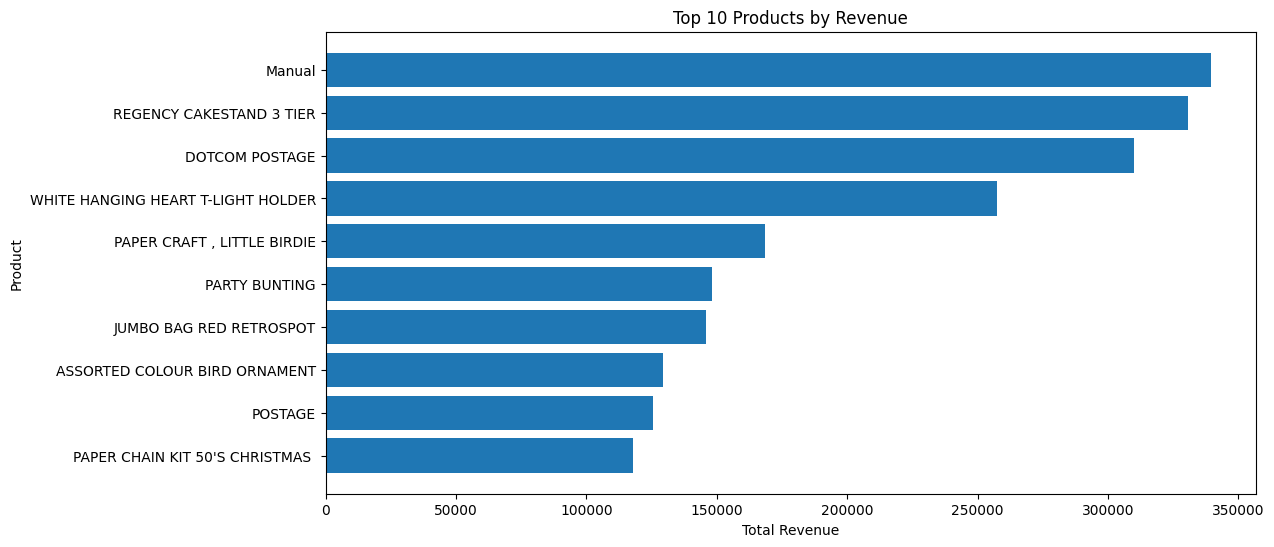

In [20]:
plt.figure(figsize=(12, 6))
plt.barh(top_10_products_revenue["description"], top_10_products_revenue["total_revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

In [21]:
top_10_products_quantity = product_summary.sort_values("total_quantity", ascending=False).head(10)
display(top_10_products_quantity)

,stockcode,description,total_revenue,total_quantity,total_orders
4171,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,24445.61,106139,1019
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807
2810,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
4967,85099B,JUMBO BAG RED RETROSPOT,145961.83,77280,3245
121,17003,BROCADE RING PURSE,14766.42,70369,456
1384,21977,PACK OF 60 PINK PAISLEY CAKE CASES,28081.73,56061,1993
4801,84991,60 TEATIME FAIRY CAKE CASES,27041.21,54028,2127
1607,22197,SMALL POPCORN HOLDER,42699.89,48561,1407


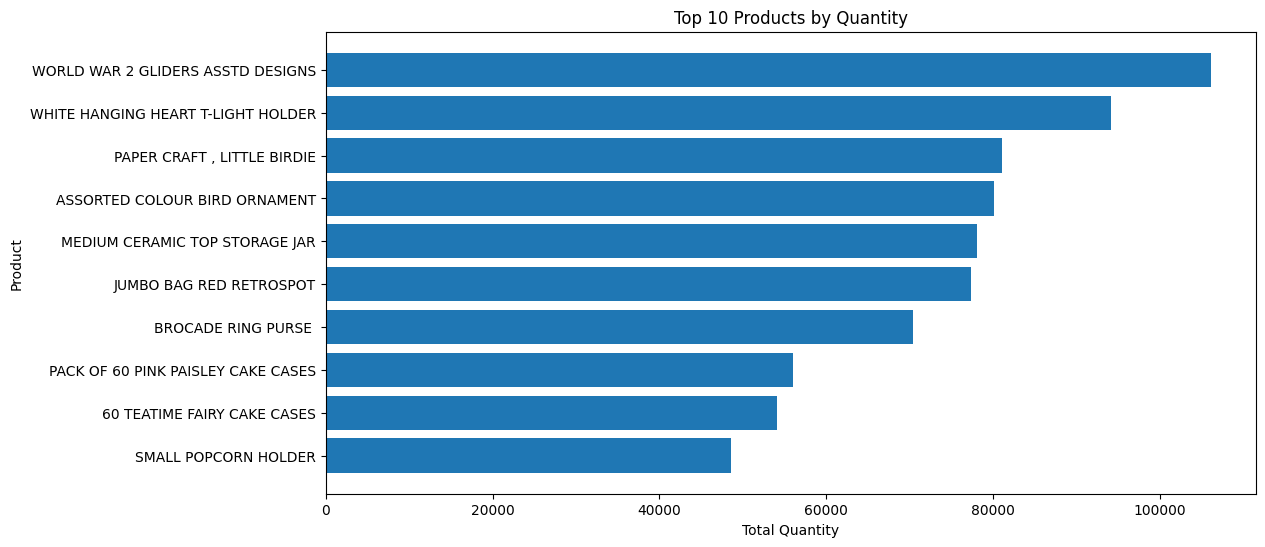

In [22]:
plt.figure(figsize=(12, 6))
plt.barh(top_10_products_quantity["description"], top_10_products_quantity["total_quantity"])
plt.title("Top 10 Products by Quantity")
plt.xlabel("Total Quantity")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

In [23]:
non_merch_codes = set(non_merchandise_codes["stockcode"].astype(str))

product_summary["is_merchandise"] = ~product_summary["stockcode"].astype(str).isin(non_merch_codes)

merch_product_summary = product_summary[product_summary["is_merchandise"]].copy()

top_10_merch_revenue = merch_product_summary.sort_values("total_revenue", ascending=False).head(10)
display(top_10_merch_revenue)

,stockcode,description,total_revenue,total_quantity,total_orders,is_merchandise
1891,22423,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918,True
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356,True
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,True
3716,47566,PARTY BUNTING,148318.28,28200,2674,True
4967,85099B,JUMBO BAG RED RETROSPOT,145961.83,77280,3245,True
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807,True
1477,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018,True
2810,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,True
4058,79321,CHILLI LIGHTS,80540.88,15841,1135,True
4227,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,71300.40,31409,756,True


## Stage 5 result — product analysis with merchandise awareness

The unfiltered product revenue ranking confirms that product analysis can be misleading if non-merchandise stock codes are not separated.

### Unfiltered top revenue entries
The top revenue list includes both merchandise and non-merchandise:

- `M` → **Manual** → **339,599.81**
- `22423` → **REGENCY CAKESTAND 3 TIER** → **330,590.32**
- `DOT` → **DOTCOM POSTAGE** → **309,854.11**
- `85123A` → **WHITE HANGING HEART T-LIGHT HOLDER** → **257,546.20**
- `23843` → **PAPER CRAFT , LITTLE BIRDIE** → **168,469.60**
- `POST` → **POSTAGE** → **125,682.42**

### Merchandise-only top revenue entries
After filtering out confirmed non-merchandise codes, the top merchandise items are:

- `22423` → **REGENCY CAKESTAND 3 TIER** → **330,590.32**
- `85123A` → **WHITE HANGING HEART T-LIGHT HOLDER** → **257,546.20**
- `23843` → **PAPER CRAFT , LITTLE BIRDIE** → **168,469.60**
- `47566` → **PARTY BUNTING** → **148,318.28**
- `85099B` → **JUMBO BAG RED RETROSPOT** → **145,961.83**

### Quantity leaders
Top quantity-based items include:

- **WORLD WAR 2 GLIDERS ASSTD DESIGNS** → **106,139**
- **WHITE HANGING HEART T-LIGHT HOLDER** → **94,142**
- **PAPER CRAFT , LITTLE BIRDIE** → **80,995**
- **ASSORTED COLOUR BIRD ORNAMENT** → **80,082**
- **MEDIUM CERAMIC TOP STORAGE JAR** → **78,033**

### Business implication
If merchandise and non-merchandise entries are mixed, dashboards can incorrectly rank postage and manual entries as if they were real products. That would make product insights professionally unreliable.

### Design implication
All product dashboards, SQL views, and PostgreSQL product logic must support explicit filtering by merchandise status. Product performance reporting should default to **merchandise-only** views, with operational/service entries shown separately where needed.

## Stage 6 — Customer concentration basics

In this stage, we build a customer-linked subset directly from the staging sales table.

The goal is not full RFM yet.  
The goal is to understand:
- how many identifiable customers exist in the staging sales data
- how concentrated customer revenue is
- whether a small number of customers drive a large share of sales

In [24]:
sales_customer = sales_main[sales_main["customer_id"].notna()].copy()

print("Customer-linked sales rows:", len(sales_customer))
print("Unique customers:", sales_customer["customer_id"].nunique())
sales_customer.head()

Customer-linked sales rows: 779425
Unique customers: 5878


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,order_date,year_month,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12-01,2009-12,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01,2009-12,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01,2009-12,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12-01,2009-12,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12-01,2009-12,12


In [25]:
customer_summary = (
    sales_customer.groupby("customer_id", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("invoice", "nunique"),
        total_quantity=("quantity", "sum"),
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max")
    )
)

display(customer_summary.head())

,customer_id,total_revenue,total_orders,total_quantity,first_purchase,last_purchase
0,12346.0,77556.46,12,74285,2009-12-14 08:34:00,2011-01-18 10:01:00
1,12347.0,4921.53,8,2967,2010-10-31 14:20:00,2011-12-07 15:52:00
2,12348.0,2019.40,5,2714,2010-09-27 14:59:00,2011-09-25 13:13:00
3,12349.0,4428.69,4,1624,2010-04-29 13:20:00,2011-11-21 09:51:00
4,12350.0,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00


In [26]:
customer_revenue_summary = customer_summary["total_revenue"].describe()
display(customer_revenue_summary)

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: total_revenue, dtype: float64

In [27]:
top_10_customers = customer_summary.sort_values("total_revenue", ascending=False).head(10)
display(top_10_customers)

,customer_id,total_revenue,total_orders,total_quantity,first_purchase,last_purchase
5692,18102.0,580987.04,145,181645,2009-12-01 09:24:00,2011-12-09 11:50:00
2277,14646.0,528602.52,151,367193,2009-12-02 16:52:00,2011-12-08 12:12:00
1789,14156.0,313437.62,156,164325,2009-12-01 12:30:00,2011-11-30 10:54:00
2538,14911.0,291420.81,398,147972,2009-12-01 11:41:00,2011-12-08 15:54:00
5050,17450.0,244784.25,51,83914,2010-09-27 16:59:00,2011-12-01 13:29:00
1331,13694.0,195640.69,143,188201,2009-12-04 15:26:00,2011-12-06 09:32:00
5109,17511.0,172132.87,60,117174,2009-12-02 10:52:00,2011-12-07 10:12:00
4061,16446.0,168472.50,2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00
4295,16684.0,147142.77,55,104810,2009-12-07 12:56:00,2011-12-05 14:06:00
68,12415.0,144458.37,28,91447,2010-06-30 08:30:00,2011-11-15 14:22:00


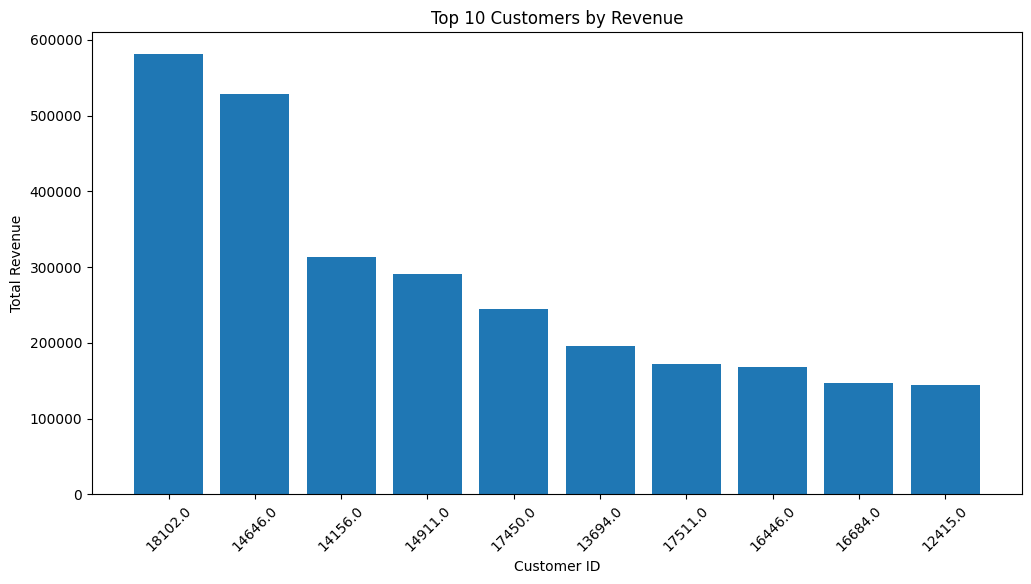

In [28]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_customers["customer_id"].astype(str), top_10_customers["total_revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

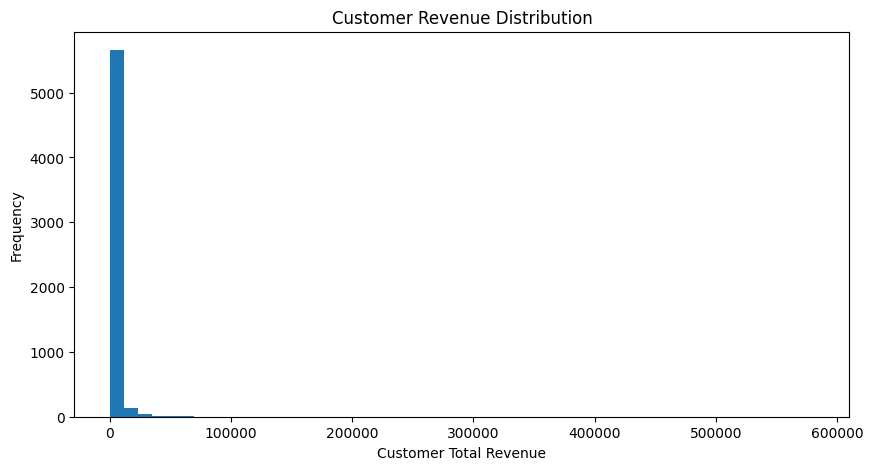

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(customer_summary["total_revenue"], bins=50)
plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Total Revenue")
plt.ylabel("Frequency")
plt.show()

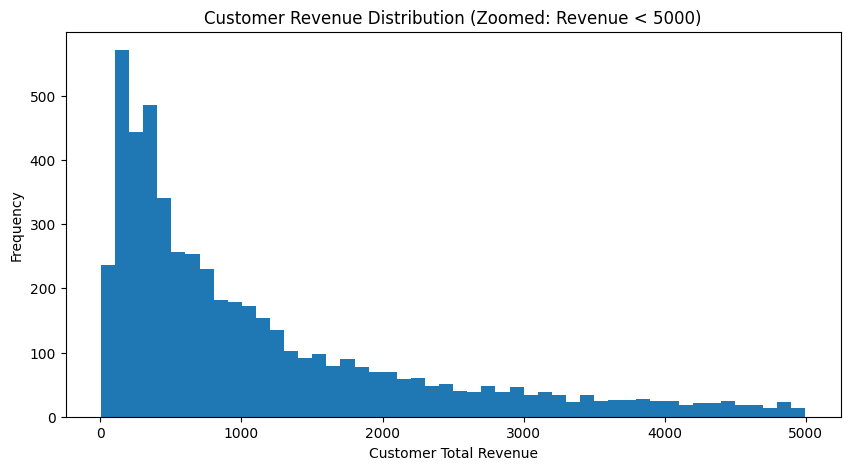

In [30]:
plt.figure(figsize=(10, 5))
plt.hist(customer_summary[customer_summary["total_revenue"] < 5000]["total_revenue"], bins=50)
plt.title("Customer Revenue Distribution (Zoomed: Revenue < 5000)")
plt.xlabel("Customer Total Revenue")
plt.ylabel("Frequency")
plt.show()

## Stage 6 result — customer concentration basics

The customer-linked staging sales subset contains **779,425 rows** across **5,878 identifiable customers**.

### Customer revenue distribution
Customer revenue is highly right-skewed:

- mean customer revenue: **2,955.90**
- median customer revenue: **867.74**
- 75th percentile: **2,248.31**
- maximum customer revenue: **580,987.04**

### Top customers by revenue
The highest-value customers are:

- `18102.0` → **580,987.04** across **145 orders**
- `14646.0` → **528,602.52** across **151 orders**
- `14156.0` → **313,437.62** across **156 orders**
- `14911.0` → **291,420.81** across **398 orders**
- `17450.0` → **244,784.25** across **51 orders**

### Business implication
Customer value is highly concentrated. A relatively small number of customers contribute a disproportionate share of revenue, which means customer retention and customer monitoring are strategically important.

### Design implication
This strongly supports the next project stages:
- PostgreSQL-based customer aggregation
- RFM segmentation
- customer monitoring views
- identification of high-value and potentially at-risk customers

It also confirms that customer analytics must be built from the **customer-linked staging subset**, not from the broader sales table that includes rows with missing customer identifiers.

## EDA conclusion — what the analysis established

The exploratory analysis established the core business behavior of the cleaned retail sales staging dataset.

### 1. Revenue scale
The staging sales dataset contains:

- **1,007,914** valid sales rows
- **20,476,634.02** total revenue
- **11,205,149** total quantity sold
- **40,078** unique invoices
- **4,917** stock codes
- **43** countries

This confirms that the project has enough scale and variety for revenue analysis, anomaly detection, customer analysis, and time-series modeling.

### 2. Geographic concentration
The **United Kingdom** contributes **17,410,569.69**, which is **85.03%** of total revenue.

**Implication:**  
Any global revenue metric is effectively UK-driven unless dashboard design explicitly separates UK vs Non-UK performance.

### 3. Seasonal behavior
Revenue is strongly seasonal, with the highest months being:

- **November** → **2,968,159.92**
- **October** → **2,313,165.95**
- **December** → **2,281,745.01**

**Implication:**  
Forecasting and anomaly detection must preserve seasonality. Year-over-year comparisons must align equivalent seasonal periods.

### 4. Product interpretation risk
The unfiltered top-product ranking includes non-merchandise entries such as:

- `M` → Manual
- `DOT` → DOTCOM POSTAGE
- `POST` → POSTAGE

**Implication:**  
Product dashboards and SQL product views must support merchandise filtering. Otherwise, product rankings will be misleading.

### 5. Customer concentration
The customer-linked staging subset contains **5,878** identifiable customers, and customer revenue is highly concentrated among a small group of top buyers.

**Implication:**  
Customer segmentation and later RFM scoring are justified and should be built from the customer-linked staging subset.

### What this means for the next project stages
The EDA results now define the requirements for the next steps:

- PostgreSQL loading must reconcile against these benchmark numbers
- product dimension design must include merchandise flags
- customer analysis must use customer-linked sales rows only
- SQL views must be validated against the EDA totals
- Tableau must support UK vs Non-UK and merchandise-aware product views